In [18]:
# ===========================================================
# NLP Document Research and Automation Pipeline
# ===========================================================

# Installing libraries
!pip -q install -U transformers huggingface_hub vaderSentiment


# ===========================================================
# 1) Imports
# ===========================================================

import re
import os
import random
import tarfile
import urllib.request
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline


# ===========================================================
# 2) Setup
# ===========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 0 if torch.cuda.is_available() else -1

print("Libraries loaded")
print(
    "Device:",
    "GPU" if torch.cuda.is_available() else "CPU"
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Libraries loaded
Device: CPU


# Document Dataset

In this section:
- the Stanford IMDB review dataset is downloaded and extracted
- 50 positive and 50 negative reviews are loaded
- the documents are cleaned and prepared for processing
- basic dataset statistics and class distribution are reported

The final dataset contains **100 labelled movie reviews**, with an average length of **221.9 words per document**.

The known positive and negative labels provide ground truth for evaluating the sentiment models later in the pipeline.

In [19]:
# ===========================================================
# 3) Loading IMDB Dataset
# ===========================================================

DATA_URL = (
    "https://ai.stanford.edu/~amaas/"
    "data/sentiment/aclImdb_v1.tar.gz"
)

DATA_FILE = "aclImdb_v1.tar.gz"
DATA_FOLDER = "aclImdb"


# Downloading dataset if needed
if not os.path.exists(DATA_FOLDER):

    print("\nDownloading IMDB dataset...")

    urllib.request.urlretrieve(
        DATA_URL,
        DATA_FILE
    )

    print("Extracting dataset...")

    with tarfile.open(
        DATA_FILE,
        "r:gz"
    ) as tar:
        tar.extractall()


print("Dataset ready")


# ===========================================================
# 4) Loading Documents
# ===========================================================

def load_reviews(folder, label, limit):

    reviews = []

    files = sorted(
        os.listdir(folder)
    )

    random.shuffle(files)

    for filename in files[:limit]:

        path = os.path.join(
            folder,
            filename
        )

        with open(
            path,
            "r",
            encoding="utf-8"
        ) as file:
            text = file.read()

        reviews.append({
            "text": text,
            "label": label
        })

    return reviews


# Loading 50 positive reviews
positive_reviews = load_reviews(
    "aclImdb/test/pos",
    "Positive",
    50
)


# Loading 50 negative reviews
negative_reviews = load_reviews(
    "aclImdb/test/neg",
    "Negative",
    50
)


documents = (
    positive_reviews
    +
    negative_reviews
)

random.shuffle(documents)

documents_df = pd.DataFrame(
    documents
)


print(
    "Documents Loaded:",
    len(documents_df)
)

print("\nClass Distribution:")

print(
    documents_df[
        "label"
    ].value_counts()
)


# ===========================================================
# 5) Text Cleaning
# ===========================================================

def clean_text(text):

    # Removing HTML
    text = re.sub(
        r"<br\s*/?>",
        " ",
        text
    )

    # Removing repeated whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


documents_df["clean_text"] = (
    documents_df["text"]
    .apply(clean_text)
)


documents_df["word_count"] = (
    documents_df["clean_text"]
    .str.split()
    .str.len()
)


print(
    "\nAverage Document Length:",
    round(
        documents_df[
            "word_count"
        ].mean(),
        1
    ),
    "words"
)

Dataset ready
Documents Loaded: 100

Class Distribution:
label
Positive    50
Negative    50
Name: count, dtype: int64

Average Document Length: 221.9 words


# Document Processing

Long documents are divided into smaller overlapping chunks before search.

In this section:
- each document is split into chunks of 100 words
- neighbouring chunks overlap by 20 words
- each chunk keeps its original document ID and sentiment label
- the chunks form the searchable document collection

The 100 documents produced **304 searchable chunks**.

The overlap helps preserve information that may otherwise be split across the boundary between two chunks.

In [20]:
# ===========================================================
# 6) Document Chunking
# ===========================================================

def chunk_document(
    text,
    chunk_size=100,
    overlap=20
):

    words = text.split()

    chunks = []

    start = 0

    while start < len(words):

        end = start + chunk_size

        chunk = " ".join(
            words[start:end]
        )

        if chunk:
            chunks.append(chunk)

        if end >= len(words):
            break

        start += (
            chunk_size
            -
            overlap
        )

    return chunks


# ===========================================================
# 7) Creating Searchable Collection
# ===========================================================

chunks = []


for document_id, row in documents_df.iterrows():

    document_chunks = chunk_document(
        row["clean_text"]
    )

    for chunk_id, chunk in enumerate(
        document_chunks
    ):

        chunks.append({
            "document_id":
                document_id,

            "chunk_id":
                chunk_id,

            "label":
                row["label"],

            "text":
                chunk
        })


chunks_df = pd.DataFrame(
    chunks
)


print(
    "Searchable Chunks:",
    len(chunks_df)
)


Searchable Chunks: 304


# Document Search

In this section:
- word-level TF-IDF represents important words and word pairs
- character-level TF-IDF captures smaller text patterns
- cosine similarity measures how closely each document chunk matches a search query
- the two similarity scores are combined to rank relevant evidence

Word similarity contributes 75% of the final retrieval score and character similarity contributes 25%.

Results are also taken from different source documents to avoid returning several similar chunks from the same review.

In [21]:
# ===========================================================
# 8) Creating Search Representations
# ===========================================================

# Word-level TF-IDF
word_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=6000,
    ngram_range=(1, 2),
    sublinear_tf=True
)


# Character-level TF-IDF
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=4000,
    sublinear_tf=True
)


# Creating vectors
word_vectors = (
    word_vectorizer.fit_transform(
        chunks_df["text"]
    )
)


char_vectors = (
    char_vectorizer.fit_transform(
        chunks_df["text"]
    )
)


print(
    "Word Matrix Shape:",
    word_vectors.shape
)

print(
    "Character Matrix Shape:",
    char_vectors.shape
)


# ===========================================================
# 9) Document Search
# ===========================================================

def search_documents(
    query,
    top_k=5
):

    # Converting query to vectors
    query_word = (
        word_vectorizer.transform(
            [query]
        )
    )

    query_char = (
        char_vectorizer.transform(
            [query]
        )
    )


    # Calculating similarity
    word_similarity = cosine_similarity(
        query_word,
        word_vectors
    )[0]

    char_similarity = cosine_similarity(
        query_char,
        char_vectors
    )[0]


    # Combining word and character similarity
    similarities = (
        0.75 * word_similarity
        +
        0.25 * char_similarity
    )


    # Ranking results
    ranked_indices = (
        similarities
        .argsort()[::-1]
    )


    results = []

    used_documents = set()


    # Selecting results from different documents
    for index in ranked_indices:

        row = chunks_df.iloc[
            index
        ]

        document_id = int(
            row["document_id"]
        )

        if document_id in used_documents:
            continue

        used_documents.add(
            document_id
        )

        results.append({
            "document_id":
                document_id,

            "chunk_id":
                int(
                    row["chunk_id"]
                ),

            "label":
                row["label"],

            "similarity":
                float(
                    similarities[index]
                ),

            "text":
                row["text"]
        })


        if len(results) >= top_k:
            break


    return pd.DataFrame(
        results
    )

Word Matrix Shape: (304, 6000)
Character Matrix Shape: (304, 4000)


# Baseline Sentiment Model

VADER is used as a lightweight baseline sentiment model before introducing the Transformer.

For each document, VADER produces:
- a positive or negative prediction
- a sentiment score representing the strength and direction of the sentiment

On the 100 labelled reviews, VADER achieved:
- **70% accuracy**
- **65.6% precision**
- **84% recall**
- **0.737 F1 score**

These results provide a baseline for determining whether the more advanced Transformer model improves sentiment classification.

In [22]:
# ===========================================================
# 10) VADER Baseline
# ===========================================================

vader_model = (
    SentimentIntensityAnalyzer()
)


def vader_sentiment(text):

    scores = (
        vader_model
        .polarity_scores(text)
    )

    score = scores[
        "compound"
    ]

    if score >= 0:
        label = "Positive"

    else:
        label = "Negative"


    return {
        "label": label,
        "score": score,
        "confidence": abs(score)
    }

# Transformer Sentiment Model

A pretrained **DistilBERT Transformer** is used as the more advanced sentiment model.

DistilBERT analyses words in context and returns:
- a positive or negative sentiment prediction
- a confidence score for the prediction

The model is used for inference only and is not trained or fine-tuned on the documents in this project.

A simple positive and negative test confirmed that the model loaded correctly and produced the expected predictions with high confidence.

In [23]:
# ===========================================================
# 11) Loading DistilBERT Transformer
# ===========================================================

print(
    "\nLoading DistilBERT Transformer..."
)


transformer_model = pipeline(
    "sentiment-analysis",
    model=(
        "distilbert/"
        "distilbert-base-uncased-finetuned-sst-2-english"
    ),
    device=device
)


print(
    "DistilBERT Transformer loaded"
)


# ===========================================================
# 12) Transformer Sentiment
# ===========================================================

def transformer_sentiment(text):

    result = transformer_model(
        text,
        truncation=True,
        max_length=512
    )[0]


    confidence = float(
        result["score"]
    )


    if result["label"].upper() == "POSITIVE":

        label = "Positive"
        score = confidence

    else:

        label = "Negative"
        score = -confidence


    return {
        "label":
            label,

        "score":
            score,

        "confidence":
            confidence
    }


# ===========================================================
# 13) Checking Transformer
# ===========================================================

positive_test = (
    "The movie had excellent acting "
    "and an interesting story."
)

negative_test = (
    "The movie had terrible acting "
    "and awful dialogue."
)


print("\nTransformer Test:")

print(
    transformer_sentiment(
        positive_test
    )
)

print(
    transformer_sentiment(
        negative_test
    )
)


Loading DistilBERT Transformer...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT Transformer loaded

Transformer Test:
{'label': 'Positive', 'score': 0.9998620748519897, 'confidence': 0.9998620748519897}
{'label': 'Negative', 'score': -0.99981290102005, 'confidence': 0.99981290102005}


# Model Validation and Comparison

VADER and DistilBERT are evaluated against the known labels of the same 100 IMDB reviews.

The following metrics are compared:
- **Accuracy** — proportion of all predictions that are correct
- **Precision** — proportion of predicted positive reviews that are actually positive
- **Recall** — proportion of actual positive reviews correctly identified
- **F1 score** — balance between precision and recall

Results:

| Model | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| VADER | 0.700 | 0.656 | **0.840** | 0.737 |
| DistilBERT Transformer | **0.840** | **0.854** | 0.820 | **0.837** |

DistilBERT improved accuracy from **70% to 84%** and F1 from **0.737 to 0.837**, while VADER achieved slightly higher recall.

Because DistilBERT achieved the higher F1 score, it is selected as the sentiment model for the final research pipeline.

In [24]:
# ===========================================================
# 14) Evaluating VADER
# ===========================================================

true_labels = (
    documents_df["label"]
    .tolist()
)


vader_predictions = []


for text in documents_df[
    "clean_text"
]:

    prediction = vader_sentiment(
        text
    )

    vader_predictions.append(
        prediction["label"]
    )


vader_accuracy = accuracy_score(
    true_labels,
    vader_predictions
)

vader_precision = precision_score(
    true_labels,
    vader_predictions,
    pos_label="Positive"
)

vader_recall = recall_score(
    true_labels,
    vader_predictions,
    pos_label="Positive"
)

vader_f1 = f1_score(
    true_labels,
    vader_predictions,
    pos_label="Positive"
)


print("\nVADER Results")

print(
    "Accuracy:",
    round(
        vader_accuracy,
        3
    )
)

print(
    "Precision:",
    round(
        vader_precision,
        3
    )
)

print(
    "Recall:",
    round(
        vader_recall,
        3
    )
)

print(
    "F1:",
    round(
        vader_f1,
        3
    )
)


# ===========================================================
# 15) Evaluating Transformer
# ===========================================================

print(
    "\nEvaluating DistilBERT..."
)


texts = (
    documents_df[
        "clean_text"
    ].tolist()
)


# Running Transformer in batches
transformer_outputs = transformer_model(
    texts,
    truncation=True,
    max_length=512,
    batch_size=16
)


transformer_predictions = []


for result in transformer_outputs:

    if result[
        "label"
    ].upper() == "POSITIVE":

        prediction = "Positive"

    else:

        prediction = "Negative"


    transformer_predictions.append(
        prediction
    )


transformer_accuracy = accuracy_score(
    true_labels,
    transformer_predictions
)

transformer_precision = precision_score(
    true_labels,
    transformer_predictions,
    pos_label="Positive"
)

transformer_recall = recall_score(
    true_labels,
    transformer_predictions,
    pos_label="Positive"
)

transformer_f1 = f1_score(
    true_labels,
    transformer_predictions,
    pos_label="Positive"
)


print(
    "\nDistilBERT Transformer Results"
)

print(
    "Accuracy:",
    round(
        transformer_accuracy,
        3
    )
)

print(
    "Precision:",
    round(
        transformer_precision,
        3
    )
)

print(
    "Recall:",
    round(
        transformer_recall,
        3
    )
)

print(
    "F1:",
    round(
        transformer_f1,
        3
    )
)


# ===========================================================
# 16) Comparing Models
# ===========================================================

comparison_df = pd.DataFrame({

    "Model": [
        "VADER",
        "DistilBERT Transformer"
    ],

    "Accuracy": [
        vader_accuracy,
        transformer_accuracy
    ],

    "Precision": [
        vader_precision,
        transformer_precision
    ],

    "Recall": [
        vader_recall,
        transformer_recall
    ],

    "F1": [
        vader_f1,
        transformer_f1
    ]
})


print(
    "\nModel Comparison:"
)

print(
    comparison_df.round(3)
)


# Selecting model using F1
if transformer_f1 >= vader_f1:

    selected_model = (
        "DistilBERT Transformer"
    )

else:

    selected_model = (
        "VADER"
    )


print(
    "\nSelected Model:",
    selected_model
)


VADER Results
Accuracy: 0.7
Precision: 0.656
Recall: 0.84
F1: 0.737

Evaluating DistilBERT...

DistilBERT Transformer Results
Accuracy: 0.84
Precision: 0.854
Recall: 0.82
F1: 0.837

Model Comparison:
                    Model  Accuracy  Precision  Recall     F1
0                   VADER      0.70      0.656    0.84  0.737
1  DistilBERT Transformer      0.84      0.854    0.82  0.837

Selected Model: DistilBERT Transformer


# Validation Results

The confusion matrix provides a breakdown of the selected DistilBERT model's predictions.

From the 100 labelled reviews:
- **43 of 50 negative reviews** were correctly classified as negative
- **41 of 50 positive reviews** were correctly classified as positive
- 7 negative reviews were incorrectly classified as positive
- 9 positive reviews were incorrectly classified as negative

Overall, DistilBERT correctly classified **84 of the 100 reviews**, consistent with its **84% validation accuracy**.

The confusion matrix shows that errors occurred in both classes rather than being concentrated entirely in one sentiment class.

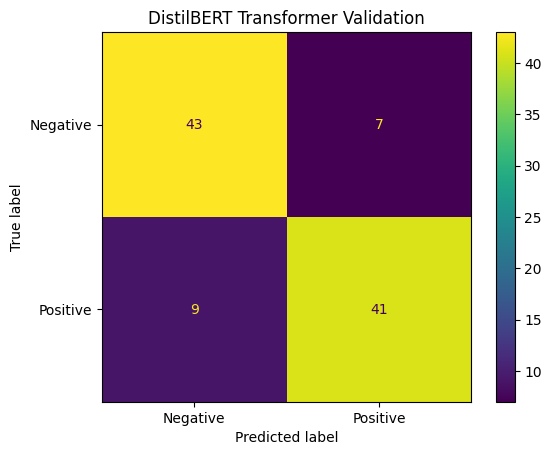

In [25]:
# ===========================================================
# 17) Confusion Matrix
# ===========================================================

if selected_model == (
    "DistilBERT Transformer"
):

    selected_predictions = (
        transformer_predictions
    )

else:

    selected_predictions = (
        vader_predictions
    )


cm = confusion_matrix(
    true_labels,
    selected_predictions,
    labels=[
        "Negative",
        "Positive"
    ]
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)


disp.plot()

plt.title(
    selected_model
    +
    " Validation"
)

plt.show()


# ===========================================================
# 18) Selected Sentiment Model
# ===========================================================

def analyse_sentiment(text):

    if selected_model == (
        "DistilBERT Transformer"
    ):

        return transformer_sentiment(
            text
        )

    else:

        return vader_sentiment(
            text
        )

# Evidence Summarisation

The retrieved document chunks are converted into a short query-focused summary.

In this section:
- retrieved evidence is split into sentences
- each sentence is compared with the research query using TF-IDF and cosine similarity
- the most relevant sentences are selected
- highly similar sentences are removed to reduce repetition

This produces an extractive summary, meaning the system selects relevant sentences from the source evidence rather than generating new information.

In [26]:
# ===========================================================
# 19) Query-Based Summarisation
# ===========================================================

def split_sentences(text):

    sentences = re.split(
        r"(?<=[.!?])\s+",
        text
    )

    return [
        sentence.strip()

        for sentence in sentences

        if len(
            sentence.split()
        ) >= 6
    ]


def summarise_results(
    results,
    query,
    max_sentences=3
):

    sentences = []


    # Collecting sentences
    for text in results[
        "text"
    ]:

        sentences.extend(
            split_sentences(
                text
            )
        )


    if len(sentences) == 0:

        return (
            results.iloc[0][
                "text"
            ][:500]
        )


    # Creating sentence vectors
    sentence_vectors = (
        word_vectorizer.transform(
            sentences
        )
    )

    query_vector = (
        word_vectorizer.transform(
            [query]
        )
    )


    # Calculating relevance
    scores = cosine_similarity(
        query_vector,
        sentence_vectors
    )[0]


    ranked_indices = (
        scores.argsort()[::-1]
    )


    selected_sentences = []
    selected_vectors = []


    for index in ranked_indices:

        sentence = sentences[
            index
        ]

        sentence_vector = (
            sentence_vectors[
                index
            ]
        )

        duplicate = False


        # Avoiding duplicate sentences
        for existing_vector in selected_vectors:

            similarity = cosine_similarity(
                sentence_vector,
                existing_vector
            )[0][0]

            if similarity > 0.65:

                duplicate = True
                break


        if not duplicate:

            selected_sentences.append(
                sentence
            )

            selected_vectors.append(
                sentence_vector
            )


        if len(
            selected_sentences
        ) >= max_sentences:

            break


    return " ".join(
        selected_sentences
    )

# Evidence Analysis

The selected DistilBERT model analyses the sentiment of each retrieved piece of evidence.

Each sentiment score is weighted by its document-search similarity score, so evidence that is more relevant to the research query has a greater influence on the overall result.

The pipeline produces:
- overall sentiment
- weighted sentiment score
- model confidence
- individual evidence predictions

This combines retrieval relevance with Transformer-based analysis rather than treating every retrieved document as equally important.

In [27]:
# ===========================================================
# 20) Analysing Retrieved Evidence
# ===========================================================

def analyse_evidence(results):

    weighted_scores = []
    weights = []

    individual_results = []


    for _, row in results.iterrows():

        sentiment = analyse_sentiment(
            row["text"]
        )


        weight = max(
            float(
                row["similarity"]
            ),
            0.001
        )


        # Weighting sentiment by search relevance
        weighted_scores.append(
            sentiment["score"]
            *
            weight
        )

        weights.append(
            weight
        )


        individual_results.append({

            "label":
                sentiment["label"],

            "score":
                sentiment["score"],

            "confidence":
                sentiment["confidence"]
        })


    overall_score = (
        sum(weighted_scores)
        /
        sum(weights)
    )


    if overall_score >= 0:

        overall_sentiment = (
            "Positive"
        )

    else:

        overall_sentiment = (
            "Negative"
        )


    return {

        "sentiment":
            overall_sentiment,

        "score":
            overall_score,

        "individual_results":
            individual_results
    }

# Human-in-the-Loop Validation

The pipeline does not automatically treat every AI output as reliable.

A result is flagged for human review when:
- the retrieved documents have a weak match with the query
- retrieved evidence contains conflicting positive and negative sentiment
- model confidence is below the defined threshold

The system does not perform the human review itself. Instead, it identifies cases where a person should inspect the evidence before the result is relied upon.

This allows routine analysis to be automated while keeping human judgement involved when the system detects uncertainty or conflicting evidence.

In [28]:
# ===========================================================
# 21) Human Review Check
# ===========================================================

def check_review(
    results,
    sentiment_result,
    retrieval_threshold=0.12,
    confidence_threshold=0.70
):

    reasons = []


    best_similarity = float(
        results[
            "similarity"
        ].max()
    )


    # Checking retrieval quality
    if best_similarity < retrieval_threshold:

        reasons.append(
            "Weak document match"
        )


    labels = [

        result["label"]

        for result in sentiment_result[
            "individual_results"
        ]
    ]


    # Checking for conflicting evidence
    if (
        "Positive" in labels
        and
        "Negative" in labels
    ):

        reasons.append(
            "Retrieved evidence has conflicting sentiment"
        )


    confidences = [

        result["confidence"]

        for result in sentiment_result[
            "individual_results"
        ]
    ]


    mean_confidence = float(
        np.mean(
            confidences
        )
    )


    # Checking model confidence
    if mean_confidence < confidence_threshold:

        reasons.append(
            "Low sentiment confidence"
        )


    return {

        "review_required":
            len(reasons) > 0,

        "reasons":
            reasons,

        "mean_confidence":
            mean_confidence
    }

# Complete Research Pipeline

The individual components are combined into one end-to-end document research workflow:

**Research Query → Document Search → Relevant Evidence → Summarisation → Transformer Analysis → Reliability Checks → Human Review Flag → Structured Output**

For each research query, the pipeline:
- searches the document collection for relevant evidence
- creates an extractive evidence-based summary
- analyses retrieved evidence using DistilBERT
- calculates retrieval similarity and model confidence
- checks whether the result should be flagged for human review
- returns the evidence and analysis in a structured form

In [29]:
# ===========================================================
# 22) Document Research Pipeline
# ===========================================================

def research_documents(
    query,
    top_k=5
):

    # Searching documents
    results = search_documents(
        query,
        top_k
    )


    # Creating summary
    summary = summarise_results(
        results,
        query
    )


    # Analysing evidence
    sentiment = analyse_evidence(
        results
    )


    # Checking reliability
    review = check_review(
        results,
        sentiment
    )


    best_similarity = float(
        results[
            "similarity"
        ].max()
    )


    mean_similarity = float(
        results[
            "similarity"
        ].mean()
    )


    return {

        "query":
            query,

        "summary":
            summary,

        "sentiment":
            sentiment[
                "sentiment"
            ],

        "sentiment_score":
            sentiment[
                "score"
            ],

        "model":
            selected_model,

        "mean_confidence":
            review[
                "mean_confidence"
            ],

        "best_similarity":
            best_similarity,

        "mean_similarity":
            mean_similarity,

        "review_required":
            review[
                "review_required"
            ],

        "review_reasons":
            review[
                "reasons"
            ],

        "evidence":
            results
    }


# ===========================================================
# 23) Displaying Research Results
# ===========================================================

def display_research(
    query,
    top_k=5
):

    result = research_documents(
        query,
        top_k
    )


    print(
        "\n"
        +
        "=" * 75
    )

    print("Research Query")

    print(
        "=" * 75
    )

    print(
        result["query"]
    )


    print("\nSummary:")

    print(
        result["summary"]
    )


    print("\nAnalysis:")

    print(
        "Model:",
        result["model"]
    )

    print(
        "Sentiment:",
        result["sentiment"]
    )

    print(
        "Sentiment Score:",
        round(
            result[
                "sentiment_score"
            ],
            3
        )
    )

    print(
        "Mean Confidence:",
        round(
            result[
                "mean_confidence"
            ],
            3
        )
    )

    print(
        "Best Similarity:",
        round(
            result[
                "best_similarity"
            ],
            3
        )
    )

    print(
        "Mean Similarity:",
        round(
            result[
                "mean_similarity"
            ],
            3
        )
    )

    print(
        "Human Review:",
        (
            "Yes"
            if result[
                "review_required"
            ]
            else "No"
        )
    )


    if result[
        "review_reasons"
    ]:

        print(
            "Review Reason:",
            "; ".join(
                result[
                    "review_reasons"
                ]
            )
        )


    print("\nRetrieved Evidence:")


    for number, (_, row) in enumerate(
        result[
            "evidence"
        ].iterrows(),
        start=1
    ):

        sentiment = analyse_sentiment(
            row["text"]
        )


        print(
            f"\nResult {number}"
        )

        print(
            "Document:",
            row["document_id"]
        )

        print(
            "Known Label:",
            row["label"]
        )

        print(
            "Similarity:",
            round(
                row["similarity"],
                3
            )
        )

        print(
            "Predicted Sentiment:",
            sentiment["label"]
        )

        print(
            "Confidence:",
            round(
                sentiment[
                    "confidence"
                ],
                3
            )
        )

        print(
            "\n",
            row["text"]
        )

# Testing the Research Pipeline

Three example research queries are used to test retrieval, summarisation, Transformer analysis and human-review logic together.

**1. Good visual effects but a disappointing story**
- sentiment: Negative
- sentiment score: -0.157
- mean confidence: 0.962
- best similarity: 0.131
- human review: **Yes**, due to conflicting sentiment in the retrieved evidence

**2. Strong acting and interesting characters**
- sentiment: Negative
- sentiment score: -0.230
- mean confidence: 0.992
- best similarity: 0.178
- human review: **Yes**, due to conflicting sentiment in the retrieved evidence

**3. Poor acting and bad dialogue**
- sentiment: Negative
- sentiment score: -1.000
- mean confidence: 1.000
- best similarity: 0.167
- human review: **No**

The examples show that high model confidence does not automatically prevent human review. The first two queries still require review because the retrieved evidence contains conflicting sentiment, while the third query produces consistent negative evidence.

In [30]:
# ===========================================================
# 24) Research Queries
# ===========================================================

query_1 = (
    "movies with good visual effects "
    "but a disappointing story"
)

query_2 = (
    "movies with strong acting "
    "and interesting characters"
)

query_3 = (
    "movies with poor acting "
    "and bad dialogue"
)


display_research(
    query_1,
    top_k=5
)

display_research(
    query_2,
    top_k=5
)

display_research(
    query_3,
    top_k=5
)


Research Query
movies with good visual effects but a disappointing story

Summary:
A good example is to say the special effects were well done, which they were. And rest assured, the residual effects of all that will probably never go away. The acting isn't great but isn't completely horrible, however the special effects - of which there are a good deal - are laughable at best.

Analysis:
Model: DistilBERT Transformer
Sentiment: Negative
Sentiment Score: -0.157
Mean Confidence: 0.962
Best Similarity: 0.131
Mean Similarity: 0.117
Human Review: Yes
Review Reason: Retrieved evidence has conflicting sentiment

Retrieved Evidence:

Result 1
Document: 87
Known Label: Positive
Similarity: 0.131
Predicted Sentiment: Positive
Confidence: 0.99

 This movie doesn't have any pretense at being great art, which is good. But it is a well written script with well developed characters and solid acting. I think if I wrote it I could do without the drama surrounding the wife, but it wasn't distracting e

# Structured Output and Automation

The final research result is converted into structured JSON containing:
- research query
- evidence-based summary
- selected NLP model
- overall sentiment and sentiment score
- model confidence
- retrieval similarity
- human-review status
- reasons for manual review

The output is also saved to `research_output.json`.

Using a structured format allows the results to be passed to another application, API or automation workflow rather than existing only as printed text.

In [31]:
# ===========================================================
# 25) Structured Output
# ===========================================================

result = research_documents(
    query_3,
    top_k=5
)


structured_output = {

    "query":
        result["query"],

    "summary":
        result["summary"],

    "model":
        result["model"],

    "sentiment":
        result["sentiment"],

    "sentiment_score":
        round(
            result[
                "sentiment_score"
            ],
            3
        ),

    "confidence":
        round(
            result[
                "mean_confidence"
            ],
            3
        ),

    "best_similarity":
        round(
            result[
                "best_similarity"
            ],
            3
        ),

    "human_review":
        result[
            "review_required"
        ],

    "review_reasons":
        result[
            "review_reasons"
        ]
}


print(
    "\n"
    +
    "=" * 75
)

print(
    "Structured Output"
)

print(
    "=" * 75
)


print(
    json.dumps(
        structured_output,
        indent=4
    )
)

# ===========================================================
# 26) Saving Output
# ===========================================================

with open(
    "research_output.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        structured_output,
        file,
        indent=4
    )


print(
    "\nOutput saved to research_output.json"
)


# ===========================================================
# 27) Project Summary
# ===========================================================

print(
    "\n"
    +
    "=" * 75
)

print(
    "Project Complete"
)

print(
    "=" * 75
)

print(
    "VADER Accuracy:",
    round(
        vader_accuracy,
        3
    )
)

print(
    "VADER F1:",
    round(
        vader_f1,
        3
    )
)

print(
    "Transformer Accuracy:",
    round(
        transformer_accuracy,
        3
    )
)

print(
    "Transformer F1:",
    round(
        transformer_f1,
        3
    )
)

print(
    "Selected Model:",
    selected_model
)

print(
    "\nPipeline:"
)

print(
    "Documents -> Chunking -> Search -> "
    "Transformer Analysis -> Summary -> "
    "Validation -> Human Review -> JSON Output"
)


Structured Output
{
    "query": "movies with poor acting and bad dialogue",
    "summary": "We have seen much better acting by R. Movies like this give classics like Lolita a bad name. Everything in this movie rang false to me...the characters, the dialogue, the manipulative soundtrack, the corny narration, all of it.",
    "model": "DistilBERT Transformer",
    "sentiment": "Negative",
    "sentiment_score": -1.0,
    "confidence": 1.0,
    "best_similarity": 0.167,
    "human_review": false,
    "review_reasons": []
}

Output saved to research_output.json

Project Complete
VADER Accuracy: 0.7
VADER F1: 0.737
Transformer Accuracy: 0.84
Transformer F1: 0.837
Selected Model: DistilBERT Transformer

Pipeline:
Documents -> Chunking -> Search -> Transformer Analysis -> Summary -> Validation -> Human Review -> JSON Output


# Project Summary
This project developed an end-to-end NLP document research and automation workflow:

**Unstructured Documents → Processing → Search → Evidence Retrieval → Summarisation → Transformer Analysis → Reliability Checks → Human Review Flag → Structured Output**

## Dataset and Processing
The pipeline was tested using **100 labelled IMDB reviews**, consisting of 50 positive and 50 negative reviews. The documents had an average length of **221.9 words** and were divided into **304 overlapping searchable chunks**.

Word and character TF-IDF representations were combined with cosine similarity to retrieve evidence relevant to a research query.


## Model Evaluation
VADER was used as a baseline and compared with a pretrained DistilBERT Transformer on the same labelled reviews.

| Model | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| VADER | 0.700 | 0.656 | **0.840** | 0.737 |
| DistilBERT Transformer | **0.840** | **0.854** | 0.820 | **0.837** |

DistilBERT increased accuracy from **70% to 84%** and F1 from **0.737 to 0.837**, so it was selected for the final pipeline.

The confusion matrix showed **43/50 negative** and **41/50 positive** reviews correctly classified, giving 84 correct predictions from 100 reviews.


## Research and Reliability
For each query, the system retrieves relevant evidence, produces an extractive summary and uses DistilBERT to analyse the sentiment of the retrieved text.

Sentiment evidence is weighted by retrieval relevance, and the system checks for:
- weak document matches
- conflicting sentiment evidence
- low model confidence

Cases that fail these checks are **flagged for human review** rather than automatically treated as reliable.

Testing showed that two queries containing mixed evidence were correctly flagged for review, while the clear query for poor acting and bad dialogue produced consistent negative evidence and did not require review.


## Automation Output
The final result is converted into structured JSON containing the query, summary, selected model, sentiment, confidence, retrieval similarity and human-review information.

This allows the analysis to be passed into another application, API or automation workflow.


## Overall Outcome
The completed project combines **information retrieval, Transformer-based NLP, quantitative model evaluation, evidence summarisation and human-in-the-loop safeguards** within one workflow.

The project demonstrates how unstructured documents can be converted into **searchable evidence, validated AI-assisted analysis and structured outputs suitable for downstream automation**.